# Gurgoan Real Estate Market Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('gurgaon_real_estate_data.csv') 
print(df.head())
print(df.shape)
print(df.info)

      Price              Status  Area Rate per sqft  \
0  10700000  Under Construction  1138         9,450   
1  14400000  Under Construction  1528         9,450   
2  10700000  Under Construction  1138         9,450   
3  40000000       Ready to move  4500         8,888   
4  24000000  Under Construction  1800        13,333   

                                       Property Type   Locality  \
0       2 BHK Apartment in M3M Antalya Hills Phase I  Sector 79   
1       3 BHK Apartment in M3M Antalya Hills Phase I  Sector 79   
2       2 BHK Apartment in M3M Antalya Hills Phase I  Sector 79   
3                            4 BHK Independent Floor  Sector 57   
4  3 BHK Independent Floor in Anant Raj Estate Plots  Sector 63   

                     Builder Name         RERA Approval  BHK_Count  \
0                            home      Approved by RERA          2   
1             Property In Gurgaon      Approved by RERA          3   
2  properties for sale in Gurgaon      Approved by RERA 

### Data Cleaning

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.drop_duplicates()

### Numerical Columns Cleaning

In [5]:
df['price'] = df["price"].astype(str).str.replace(",", "").astype(float)
df['area'] = df["area"].astype(str).str.replace(",", "").astype(int)
df['rate_per_sqft'] = df['rate_per_sqft'].astype(str).str.replace(",", "").astype(int)

### Categorical Columns Cleaning

In [6]:
df['status'] = df['status'].str.strip().str.lower()
df['rera_approval'] = df['rera_approval'].str.strip().str.lower().map({'approved by rera': True, 'not approved by rera': False})
df['flat_type'] = df['flat_type'].str.strip().str.lower()

In [7]:
df = df.drop_duplicates()

In [8]:
print(df)
print(df.info())

            price              status  area  rate_per_sqft  \
0      10700000.0  under construction  1138           9450   
1      14400000.0  under construction  1528           9450   
2      10700000.0  under construction  1138           9450   
3      40000000.0       ready to move  4500           8888   
4      24000000.0  under construction  1800          13333   
...           ...                 ...   ...            ...   
19510  24100000.0       ready to move  1381          17500   
19511  36200000.0       ready to move  2072          17500   
19512  39100000.0  under construction  2445          16002   
19513  37700000.0  under construction  2360          16001   
19514  36500000.0  under construction  2282          16005   

                                           property_type    locality  \
0           2 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
1           3 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
2           2 BHK Apartment in M3M Anta

In [9]:
print(df.columns)

Index(['price', 'status', 'area', 'rate_per_sqft', 'property_type', 'locality',
       'builder_name', 'rera_approval', 'bhk_count', 'society', 'company_name',
       'flat_type'],
      dtype='object')


#### Question 1: Which is the costliest flat in the dataset?

In [10]:
costliest_flat = df.loc[df['price'].idxmax()]
print(f"The costliest flat is a {costliest_flat['bhk_count']} BHK flat located in {costliest_flat['locality']} priced at {costliest_flat['price']/10000000} crores in {costliest_flat['society']} society.")

The costliest flat is a 6 BHK flat located in Sector 42 priced at 122.63 crores in  DLF Camellias society.


#### Question 2: Which locality has the highest average price?

In [11]:
highest_avg_price_locality = df.groupby('locality')['price'].mean().idxmax()
print(f"The locality with the highest average price is {highest_avg_price_locality}.")

The locality with the highest average price is Baliawas.


#### Question 3: Which locality has the highest rate per square foot?

In [12]:
highest_rate_locality = df.groupby('locality')['rate_per_sqft'].mean().idxmax()
print(f"The locality with the highest rate per square foot is {highest_rate_locality}.")

The locality with the highest rate per square foot is Sector 42.


#### Question 4: Do ready-to-move properties cost more than under-construction properties?

In [13]:
ready_to_move_avg_price = df[df['status'] == 'ready to move']['price'].mean()
under_construction_avg_price = df[df['status'] == 'under construction']['price'].mean()

if ready_to_move_avg_price > under_construction_avg_price:
    print("Ready-to-move properties cost more on average than under-construction properties.")
else:
    print("Under-construction properties cost more on average than ready-to-move properties.")


Ready-to-move properties cost more on average than under-construction properties.


#### Question 5: Do RERA-approved properties command a price premium?

In [14]:
rera_approved_avg_price = df[df['rera_approval'] == True]['price'].mean()
rera_not_approved_avg_price = df[df['rera_approval'] == False]['price'].mean()

if rera_approved_avg_price > rera_not_approved_avg_price:
    print("RERA-approved properties command a price premium.")
else:
    print("RERA-approved properties do not command a price premium.")

RERA-approved properties do not command a price premium.


#### Question 6: How does area impact price?

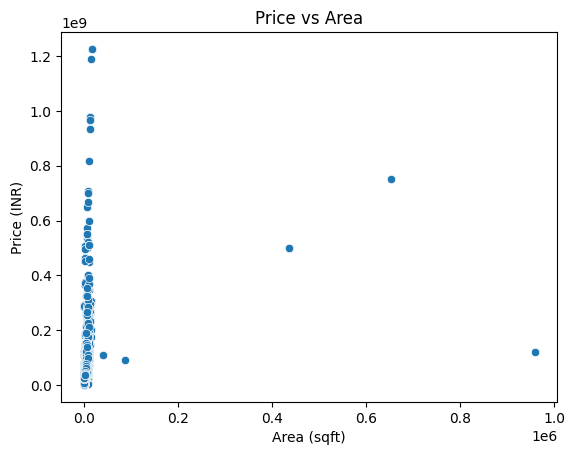

In [15]:
sns.scatterplot(data=df, x='area', y='price')
plt.title('Price vs Area')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (INR)')
plt.show()

#### Question 7: Which BHK configuration is most expensive based on per sqft rate?

In [16]:
most_expensive_bhk = df.groupby('bhk_count')['rate_per_sqft'].mean().idxmax()
print(f"The most expensive BHK configuration on average is {most_expensive_bhk} BHK.")

The most expensive BHK configuration on average is 114 BHK.


#### Question 8: Which property type is the costliest?

In [17]:
most_expensive_property_type = df.groupby('flat_type')['rate_per_sqft'].mean().idxmax()
print(f"The most expensive property type is {most_expensive_property_type}.")

The most expensive property type is villa.


#### Question 9: Do certain builders price higher?

In [18]:
print(df.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False).head(5))
#print name of top 5 

company_name
Camelliaass    44724.333333
Cameliaas      40000.000000
Tulip          28571.121495
Prom           27358.600000
Magnoliaass    26666.000000
Name: rate_per_sqft, dtype: float64


In [19]:
print("The top 5 builders that price higher are:", end=" ")
top_5_builders = df.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False).head(5)
for builder in top_5_builders.index:
    print(builder, end=", ")

The top 5 builders that price higher are: Camelliaass, Cameliaas, Tulip, Prom, Magnoliaass, 

#### Question 10: Are larger homes more expensive per sqft?

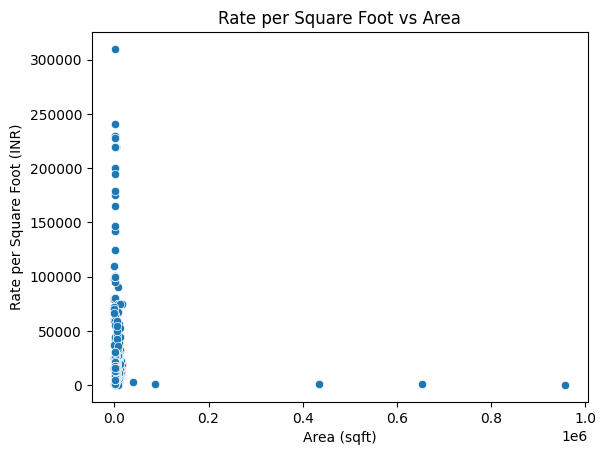

In [21]:
sns.scatterplot(data=df, x='area', y='rate_per_sqft')
plt.title('Rate per Square Foot vs Area')
plt.xlabel('Area (sqft)')
plt.ylabel('Rate per Square Foot (INR)')
plt.show()